5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

        zero       0.87      1.00      0.93        13
         one       1.00      0.81      0.90        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.56      0.71         9
        five       0.91      0.91      0.91        23
         six       1.00      0.64      0.78        11
       seven       0.73      1.00      0.84        16
       eight       0.94      0.94      0.94        16
        nine       0.89      0.96      0.92        25

    accuracy                           0.90       160
   macro avg       0.92      0.87      0.88       160
weighted avg       0.91      0.90      0.90       160



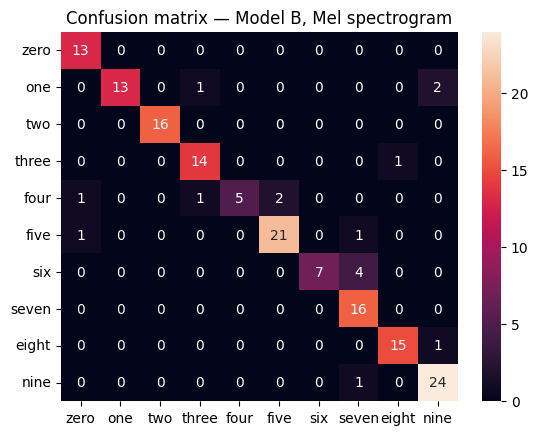

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR, DATA_DIR


model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "deep_model-melSpectrogram.keras"))

digits = ['zero','one','two','three','four','five','six','seven','eight','nine']


X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))


test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("confusion_matrix.png")


print(classification_report(y_true, y_pred, target_names=digits))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

        zero       1.00      1.00      1.00        13
         one       1.00      0.94      0.97        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.78      0.88         9
        five       1.00      0.96      0.98        23
         six       1.00      1.00      1.00        11
       seven       1.00      1.00      1.00        16
       eight       0.88      0.94      0.91        16
        nine       0.96      0.96      0.96        25
     silence       0.99      1.00      1.00       257

    accuracy                           0.98       417
   macro avg       0.97      0.95      0.96       417
weighted avg       0.98      0.98      0.98       417



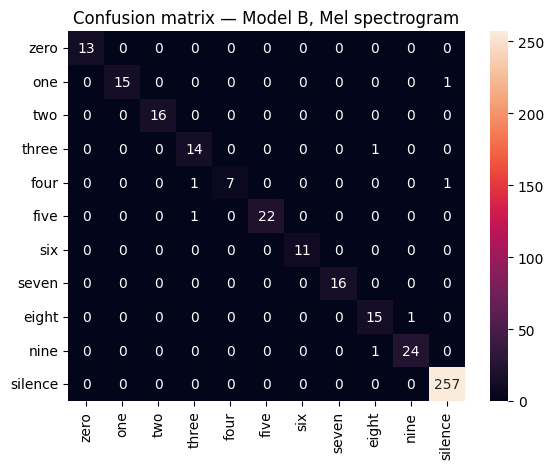

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR, DATA_DIR


model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "best_baselineModel_augmented.keras"))

digits = ['zero','one','two','three','four','five','six','seven','eight','nine', 'silence']


X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel_11class.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_11class.npy"))


test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("augmentedModel_confusion_matrix.png")


print(classification_report(y_true, y_pred, target_names=digits))


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

/Users/nicolas/Documents/GitHub/DAT255-Project-V26-Gr30/speech_env/lib/python3.13/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


=== AST Transformer (pretrained, digits only) ===
              precision    recall  f1-score   support

        zero       1.00      1.00      1.00        13
         one       1.00      0.94      0.97        16
         two       1.00      1.00      1.00        16
       three       1.00      1.00      1.00        15
        four       1.00      1.00      1.00         9
        five       1.00      1.00      1.00        23
         six       1.00      1.00      1.00        11
       seven       1.00      1.00      1.00        16
       eight       1.00      1.00      1.00        16
        nine       1.00      1.00      1.00        25

   micro avg       1.00      0.99      1.00       160
   macro avg       1.00      0.99      1.00       160
weighted avg       1.00      0.99      1.00       160

Time: 80.5 ms per sample


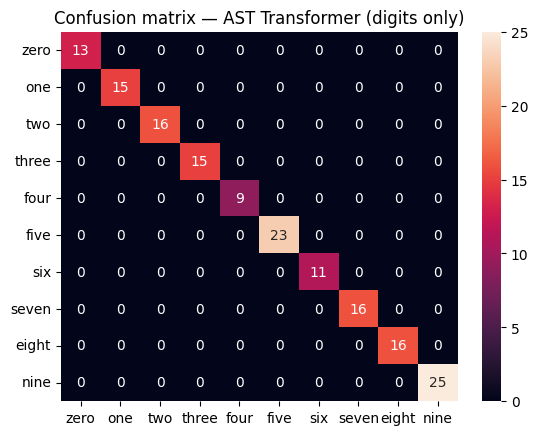

In [24]:
from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

dataset = load_dataset("google/speech_commands", "v0.01")
label_names = dataset["test"].features["label"].names

DIGIT_LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine']
digit_ids = {label_names.index(d) for d in DIGIT_LABELS if d in label_names}
label_to_idx = {d: i for i, d in enumerate(DIGIT_LABELS)}

# Only digit samples — AST has no silence class
test_digits = dataset["test"].filter(lambda x: x["label"] in digit_ids)

classifier = pipeline("audio-classification", model="MIT/ast-finetuned-speech-commands-v2")

y_true, y_pred_ast = [], []
start = time.time()

for sample in test_digits:
    audio = np.array(sample["audio"]["array"], dtype=np.float32)
    true_label = label_names[sample["label"]]
    pred_label = classifier(audio, sampling_rate=16000)[0]["label"]
    y_true.append(label_to_idx[true_label])
    y_pred_ast.append(label_to_idx.get(pred_label, -1))  # -1 for non-digit predictions

elapsed = time.time() - start

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_ast, labels=list(range(10)))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=DIGIT_LABELS, yticklabels=DIGIT_LABELS)
plt.title("Confusion matrix — AST Transformer (digits only)")
plt.savefig("ast_confusion_matrix.png")

print("=== AST Transformer (pretrained, digits only) ===")
print(classification_report(y_true, y_pred_ast, labels=list(range(10)), target_names=DIGIT_LABELS, zero_division=0))
print(f"Time: {elapsed / len(test_digits) * 1000:.1f} ms per sample")


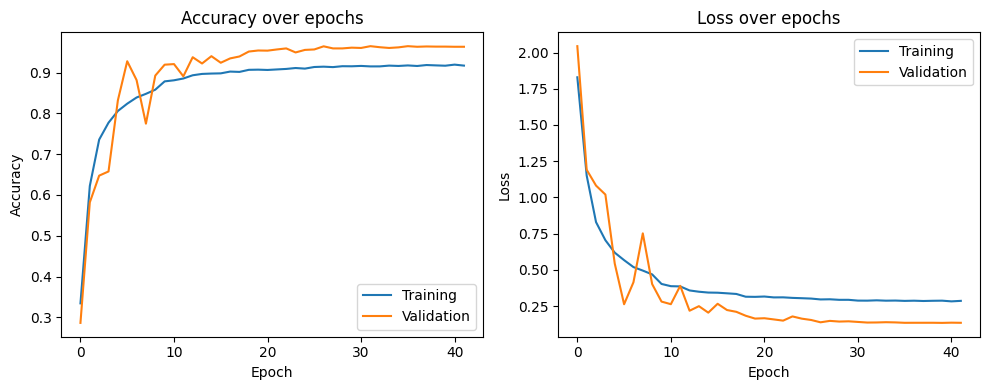

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import RESULTS_DIR

history = np.load(os.path.join(RESULTS_DIR, "best_baselineModel_augmented_history.npy"), allow_pickle=True).item()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


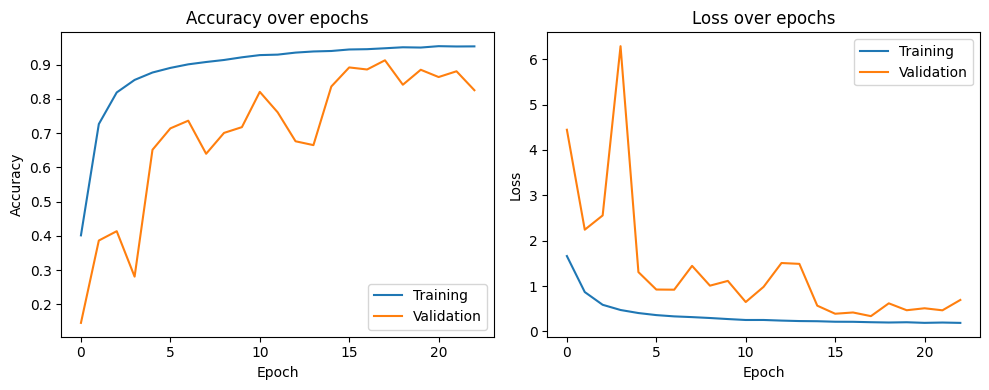

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import RESULTS_DIR

history = np.load(os.path.join(RESULTS_DIR, "deep_model-melSpectrogram_history.npy"), allow_pickle=True).item()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


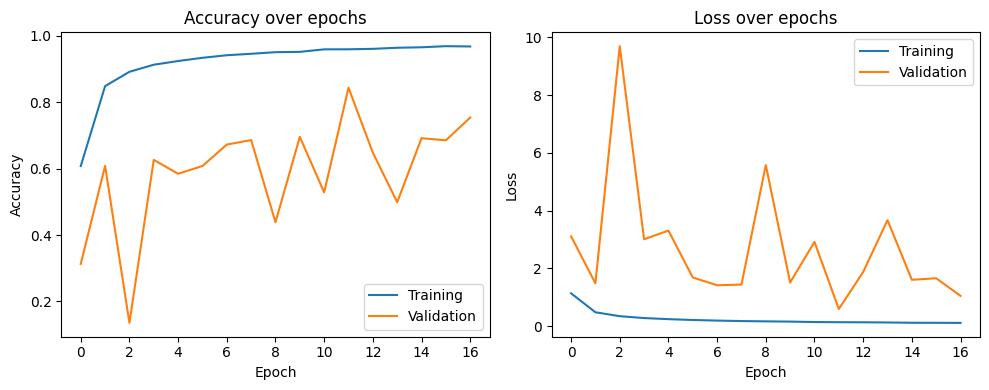

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import RESULTS_DIR

history = np.load(os.path.join(RESULTS_DIR, "deep_model-mfcc_history.npy"), allow_pickle=True).item()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


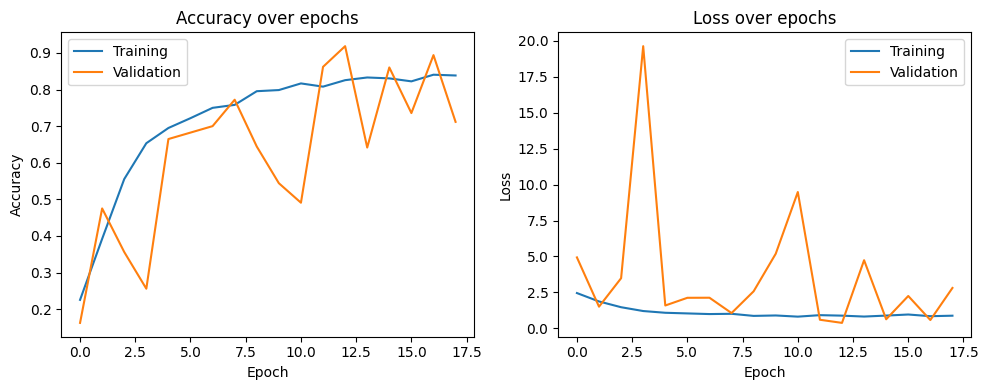

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import RESULTS_DIR

history = np.load(os.path.join(RESULTS_DIR, "deep_model-mel-lr0.01_history.npy"), allow_pickle=True).item()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from config import RESULTS_DIR

models = [
    "shallow_model-melSpectrogram",
    "shallow_model-mfcc",
    "deep_model-melSpectrogram",
    "deep_model-mfcc",
    "deep_model-mel-lr0.01",
    "best_baselineModel_augmented",
]

for name in models:
    history = np.load(os.path.join(RESULTS_DIR, f"{name}_history.npy"), allow_pickle=True).item()
    print(f"{name}")
    print(f"  Final training accuracy : {history['accuracy'][-1]:.4f}")
    print(f"  Best validation accuracy: {max(history['val_accuracy']):.4f}")
    print()


shallow_model-melSpectrogram
  Final training accuracy : 0.4015
  Best validation accuracy: 0.6508

shallow_model-mfcc
  Final training accuracy : 0.8600
  Best validation accuracy: 0.8536

deep_model-melSpectrogram
  Final training accuracy : 0.9537
  Best validation accuracy: 0.9130

deep_model-mfcc
  Final training accuracy : 0.9678
  Best validation accuracy: 0.8436

deep_model-mel-lr0.01
  Final training accuracy : 0.8385
  Best validation accuracy: 0.9186

best_baselineModel_augmented
  Final training accuracy : 0.9169
  Best validation accuracy: 0.9645



In [ ]:
import os, time, gc
import numpy as np
import tensorflow as tf
import psutil
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
import torch
import sys
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR

def file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

cnn_path = os.path.join(MODEL_DIR, "deep_model-melSpectrogram.keras")
print(f"CNN file size:  {file_size_mb(cnn_path):.2f} MB")


cnn = tf.keras.models.load_model(cnn_path)


dummy = np.random.rand(1, 64, 101, 1).astype(np.float32)
for _ in range(10):
    cnn.predict(dummy, verbose=0)


N = 100
times = []
for _ in range(N):
    t0 = time.perf_counter()
    cnn.predict(dummy, verbose=0)
    times.append((time.perf_counter() - t0) * 1000)  # ms
print(f"CNN inference: mean {np.mean(times):.2f} ms, "
      f"std {np.std(times):.2f} ms, "
      f"median {np.median(times):.2f} ms")

process = psutil.Process(os.getpid())
gc.collect()
mem_before = process.memory_info().rss / (1024 * 1024)
_ = cnn.predict(dummy, verbose=0)
mem_after  = process.memory_info().rss / (1024 * 1024)
print(f"CNN process RAM: {mem_before:.1f} MB → {mem_after:.1f} MB")


ast_id = "MIT/ast-finetuned-speech-commands-v2"
extractor = AutoFeatureExtractor.from_pretrained(ast_id)
ast = AutoModelForAudioClassification.from_pretrained(ast_id)
ast.eval()


ast_dir = ast.config._name_or_path  # cache path
ast_size = sum(file_size_mb(os.path.join(r, f))
               for r, _, files in os.walk(os.path.expanduser("~/.cache/huggingface"))
               for f in files if ast_id.split("/")[-1] in r and f.endswith(".bin") or f.endswith(".safetensors"))
print(f"AST file size:  {ast_size:.2f} MB")

dummy_audio = np.random.randn(16000).astype(np.float32)
inputs = extractor(dummy_audio, sampling_rate=16000, return_tensors="pt")

with torch.no_grad():
    for _ in range(10):
        ast(**inputs) 

times = []
with torch.no_grad():
    for _ in range(N):
        t0 = time.perf_counter()
        ast(**inputs)
        times.append((time.perf_counter() - t0) * 1000)
print(f"AST inference: mean {np.mean(times):.2f} ms, "
      f"std {np.std(times):.2f} ms, "
      f"median {np.median(times):.2f} ms")

CNN file size:  1.54 MB
CNN inference: mean 22.01 ms, std 4.57 ms, median 20.67 ms
CNN process RAM: 668.1 MB → 668.4 MB


/Users/nicolas/Documents/GitHub/DAT255-Project-V26-Gr30/speech_env/lib/python3.13/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST inference: mean 41.81 ms, std 3.08 ms, median 41.07 ms
